# Model Training and Evaluation

This notebook trains and evaluates multiple machine learning models for customer churn prediction.

In [1]:
# Install required packages
# %pip install pandas scikit-learn pyarrow xgboost lightgbm imbalanced-learn


# Imports
import pandas as pd
import numpy as np
from pathlib import Path
import pickle

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.base import clone
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot as plt
import seaborn as sns

# Try importing XGBoost and LightGBM (optional)
try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost not available")

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print("LightGBM not available")

In [2]:
# Configuration
PROCESSED_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

In [3]:
# Load processed data
print("=== Loading Processed Data ===")

# Use engineered features if available, otherwise fall back to basic processed data
engineered_train_path = PROCESSED_DIR / "train_engineered.parquet"
engineered_test_path = PROCESSED_DIR / "test_engineered.parquet"

if engineered_train_path.exists() and engineered_test_path.exists():
    print("Using engineered features...")
    X_train = pd.read_parquet(engineered_train_path)
    X_test = pd.read_parquet(engineered_test_path)
else:
    print("Using basic processed features...")
    X_train = pd.read_parquet(PROCESSED_DIR / "train.parquet")
    X_test = pd.read_parquet(PROCESSED_DIR / "test.parquet")

# Single-column label frames -> Series via iloc[:, 0]
# (statically typed as Series, unlike .squeeze() which may return a scalar)
y_train = pd.read_parquet(PROCESSED_DIR / "train_labels.parquet").iloc[:, 0]
y_test = pd.read_parquet(PROCESSED_DIR / "test_labels.parquet").iloc[:, 0]

print(f"Training features: {X_train.shape}")
print(f"Test features: {X_test.shape}")
print(f"Training labels: {y_train.shape}")
print(f"Test labels: {y_test.shape}")

=== Loading Processed Data ===
Using engineered features...
Training features: (5625, 78)
Test features: (1407, 78)
Training labels: (5625,)
Test labels: (1407,)


In [4]:
# Prepare features (remove customerID) and ensure binary labels
print("=== Preparing Features ===")

customer_id_train = X_train['customerID']
customer_id_test = X_test['customerID']

X_train_features = X_train.drop(columns=['customerID'])
X_test_features = X_test.drop(columns=['customerID'])

# Ensure labels are binary 0/1 with 1 = churn.
# The processed parquet may store labels as ints (0/1) or strings ('Yes'/'No'),
# depending on the preprocessing version. Normalize both to 0/1 so every
# downstream step (metrics, scale_pos_weight, SMOTE, threshold tuning) is consistent.
def to_binary(y):
    y = pd.Series(np.asarray(y).ravel())
    if y.dtype == object:
        return (y == 'Yes').astype(int)
    return y.astype(int)

y_train = to_binary(y_train)
y_test = to_binary(y_test)

print(f"Training features (without ID): {X_train_features.shape}")
print(f"Test features (without ID): {X_test_features.shape}")
print(f"Feature columns: {list(X_train_features.columns)}")
print(f"\nTrain label distribution (0=No churn, 1=Churn):")
print(y_train.value_counts().sort_index().to_dict())

=== Preparing Features ===
Training features (without ID): (5625, 77)
Test features (without ID): (1407, 77)
Feature columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Female', 'gender_Male', 'Partner_No', 'Partner_Yes', 'Dependents_No', 'Dependents_Yes', 'PhoneService_No', 'PhoneService_Yes', 'MultipleLines_No', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_Month-to-month', 'Contract_One year', 'Contra

## Handling Class Imbalance

### What it is
The target `Churn` is imbalanced: about **73% "No" vs. 27% "Yes"** (~2.77 : 1). A model can
score ~73% accuracy simply by predicting "no churn" for everyone, so plain accuracy and even
ROC-AUC can look fine while the model **misses half of the real churners** (low recall on the
minority class). For churn, recall on the positive (churn) class is usually the metric that
matters most — a missed churner is a lost customer.

Q: Why does this happen?

### How we handle it
We apply three complementary techniques and compare them:

1. **Class weighting** (`class_weight='balanced'`, or `scale_pos_weight` for XGBoost/LightGBM,
   or `sample_weight` for Gradient Boosting). Re-weights the loss so minority-class errors count
   more. Cheap, no new dependencies, no leakage risk — our primary fix.
2. **Threshold tuning.** Adjusts the decision cutoff applied to predicted probabilities to pick
   an explicit precision/recall operating point. Complements class weighting (it changes how we
   *act* on predictions, not how the model *learns*).
3. **SMOTE oversampling** (benchmark). Synthesizes minority examples on the training set only.
   An *alternative* to class weighting, included for comparison rather than stacked with it.

### Why
- **Baselines are kept** so we can measure the lift from balancing.
- **class_weight/scale_pos_weight** is the recommended default: minimal, safe, and effective.
- **Threshold tuning** turns "imbalance" into a concrete, defensible business decision
  (e.g. "catch >=70% of churners").
- **ROC-AUC will barely move** with balancing because it is threshold-independent — so we
  evaluate success primarily via **churn-class recall and F1**, expecting precision to drop
  somewhat as recall rises.

In [5]:
# Define evaluation function
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, fit_kwargs=None):
    """Train and evaluate a model with comprehensive metrics.

    Labels are binary 0/1 (1 = churn), so precision/recall/F1 report the
    positive (churn) class by default. `fit_kwargs` lets callers pass extras
    such as sample_weight (used for the balanced Gradient Boosting variant,
    which has no class_weight parameter).
    """
    print(f"\n=== {model_name} ===")

    fit_kwargs = fit_kwargs or {}

    # Train model
    model.fit(X_train, y_train, **fit_kwargs)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Probability of the positive class (churn = 1) for ROC-AUC
    if hasattr(model, 'predict_proba'):
        pos_idx = list(model.classes_).index(1)
        y_train_proba = model.predict_proba(X_train)[:, pos_idx]
        y_test_proba = model.predict_proba(X_test)[:, pos_idx]
    else:
        y_train_proba = y_train_pred
        y_test_proba = y_test_pred

    # Metrics (positive class = 1 = churn)
    metrics = {
        'model': model_name,
        'train_accuracy': accuracy_score(y_train, y_train_pred),
        'test_accuracy': accuracy_score(y_test, y_test_pred),
        'train_precision': precision_score(y_train, y_train_pred),
        'test_precision': precision_score(y_test, y_test_pred),
        'train_recall': recall_score(y_train, y_train_pred),
        'test_recall': recall_score(y_test, y_test_pred),
        'train_f1': f1_score(y_train, y_train_pred),
        'test_f1': f1_score(y_test, y_test_pred),
        'train_roc_auc': roc_auc_score(y_train, y_train_proba),
        'test_roc_auc': roc_auc_score(y_test, y_test_proba)
    }

    # Print metrics
    print(f"Train Accuracy: {metrics['train_accuracy']:.4f}")
    print(f"Test Accuracy: {metrics['test_accuracy']:.4f}")
    print(f"Train Precision: {metrics['train_precision']:.4f}")
    print(f"Test Precision: {metrics['test_precision']:.4f}")
    print(f"Train Recall: {metrics['train_recall']:.4f}")
    print(f"Test Recall: {metrics['test_recall']:.4f}")
    print(f"Train F1: {metrics['train_f1']:.4f}")
    print(f"Test F1: {metrics['test_f1']:.4f}")
    print(f"Train ROC-AUC: {metrics['train_roc_auc']:.4f}")
    print(f"Test ROC-AUC: {metrics['test_roc_auc']:.4f}")

    # Classification report
    print("\nClassification Report (Test):")
    print(classification_report(y_test, y_test_pred))

    return model, metrics

In [6]:
# Initialize models: baseline vs. class-imbalance-aware (balanced) variants
print("=== Initializing Models ===")

# scale_pos_weight for boosting libraries = n_negative / n_positive
n_neg = int((y_train == 0).sum())
n_pos = int((y_train == 1).sum())
scale_pos_weight = n_neg / n_pos
print(f"Imbalance ratio (No:Yes) = {scale_pos_weight:.2f}:1  ->  scale_pos_weight = {scale_pos_weight:.2f}")

# Baseline models (no imbalance handling) — kept so we can measure the lift.
models = {
    'Logistic Regression': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE, n_estimators=100),
}

# Balanced variants — re-weight the minority (churn) class.
#   * LogisticRegression / RandomForest: class_weight='balanced' (weights ~ inverse class frequency).
#   * GradientBoosting: no class_weight param -> we pass sample_weight at fit time (see training loop).
#   * XGBoost / LightGBM: use scale_pos_weight (= n_neg / n_pos).
models['Logistic Regression (balanced)'] = LogisticRegression(
    random_state=RANDOM_STATE, max_iter=1000, class_weight='balanced')
models['Random Forest (balanced)'] = RandomForestClassifier(
    random_state=RANDOM_STATE, n_estimators=100, class_weight='balanced')
models['Gradient Boosting (balanced)'] = GradientBoostingClassifier(
    random_state=RANDOM_STATE, n_estimators=100)  # balanced via sample_weight below

if HAS_XGB:
    models['XGBoost'] = xgb.XGBClassifier(random_state=RANDOM_STATE, n_estimators=100)
    models['XGBoost (balanced)'] = xgb.XGBClassifier(
        random_state=RANDOM_STATE, n_estimators=100, scale_pos_weight=scale_pos_weight)

if HAS_LGB:
    models['LightGBM'] = lgb.LGBMClassifier(random_state=RANDOM_STATE, n_estimators=100)
    models['LightGBM (balanced)'] = lgb.LGBMClassifier(
        random_state=RANDOM_STATE, n_estimators=100, scale_pos_weight=scale_pos_weight)

# Models whose balancing is applied through sample_weight rather than a constructor arg
SAMPLE_WEIGHT_MODELS = {'Gradient Boosting (balanced)'}

print(f"Models to train: {list(models.keys())}")

=== Initializing Models ===
Imbalance ratio (No:Yes) = 2.76:1  ->  scale_pos_weight = 2.76
Models to train: ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'Logistic Regression (balanced)', 'Random Forest (balanced)', 'Gradient Boosting (balanced)', 'XGBoost', 'XGBoost (balanced)', 'LightGBM', 'LightGBM (balanced)']


In [7]:
# Train and evaluate all models
print("=== Training and Evaluating Models ===")

# Balanced sample weights (inverse class frequency) for models that can't take class_weight
sample_weights = compute_sample_weight('balanced', y_train)

results = []
trained_models = {}

for model_name, model in models.items():
    fit_kwargs = {'sample_weight': sample_weights} if model_name in SAMPLE_WEIGHT_MODELS else None
    trained_model, metrics = evaluate_model(
        model, X_train_features, X_test_features, y_train, y_test, model_name,
        fit_kwargs=fit_kwargs
    )
    trained_models[model_name] = trained_model
    results.append(metrics)

=== Training and Evaluating Models ===

=== Logistic Regression ===
Train Accuracy: 0.8089
Test Accuracy: 0.7925
Train Precision: 0.6641
Test Precision: 0.6314
Train Recall: 0.5686
Test Recall: 0.5267
Train F1: 0.6126
Test F1: 0.5743
Train ROC-AUC: 0.8529
Test ROC-AUC: 0.8300

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.53      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407


=== Random Forest ===
Train Accuracy: 1.0000
Test Accuracy: 0.7761
Train Precision: 1.0000
Test Precision: 0.6073
Train Recall: 1.0000
Test Recall: 0.4465
Train F1: 1.0000
Test F1: 0.5146
Train ROC-AUC: 1.0000
Test ROC-AUC: 0.8125

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.82      0.90      0.85    

In [8]:
# Compare model performance
print("=== Model Comparison ===")

results_df = pd.DataFrame(results)
results_df = results_df.set_index('model')

# Display comparison
print(results_df.round(4))

# Find best model by test ROC-AUC (threshold-independent ranking metric)
best_model_name = results_df['test_roc_auc'].idxmax()
best_score = results_df['test_roc_auc'].max()
print(f"\nBest Model by ROC-AUC: {best_model_name} (ROC-AUC: {best_score:.4f})")

# --- Class-imbalance impact: baseline vs. balanced ---
# Recall on the churn class is the metric most affected by imbalance handling.
print("\n=== Impact of Class-Weight Balancing (test recall & F1) ===")
pairs = [
    ('Logistic Regression', 'Logistic Regression (balanced)'),
    ('Random Forest', 'Random Forest (balanced)'),
    ('Gradient Boosting', 'Gradient Boosting (balanced)'),
]
if HAS_XGB:
    pairs.append(('XGBoost', 'XGBoost (balanced)'))
if HAS_LGB:
    pairs.append(('LightGBM', 'LightGBM (balanced)'))

impact_rows = []
for base, bal in pairs:
    if base in results_df.index and bal in results_df.index:
        impact_rows.append({
            'model': base.replace(' (balanced)', ''),
            'recall_baseline': results_df.loc[base, 'test_recall'],
            'recall_balanced': results_df.loc[bal, 'test_recall'],
            'recall_delta': results_df.loc[bal, 'test_recall'] - results_df.loc[base, 'test_recall'],
            'f1_baseline': results_df.loc[base, 'test_f1'],
            'f1_balanced': results_df.loc[bal, 'test_f1'],
            'precision_baseline': results_df.loc[base, 'test_precision'],
            'precision_balanced': results_df.loc[bal, 'test_precision'],
        })
impact_df = pd.DataFrame(impact_rows).set_index('model')
print(impact_df.round(4))
print("\nReading this table: balancing should RAISE recall (catch more churners),"
      "\nusually at the cost of some precision (more false alarms). Judge the trade-off via F1.")

=== Model Comparison ===
                                train_accuracy  test_accuracy  \
model                                                           
Logistic Regression                     0.8089         0.7925   
Random Forest                           1.0000         0.7761   
Gradient Boosting                       0.8372         0.7953   
Logistic Regression (balanced)          0.7554         0.7328   
Random Forest (balanced)                0.9989         0.7669   
Gradient Boosting (balanced)            0.7945         0.7328   
XGBoost                                 0.9897         0.7669   
XGBoost (balanced)                      0.9838         0.7534   
LightGBM                                0.9243         0.7804   
LightGBM (balanced)                     0.9022         0.7477   

                                train_precision  test_precision  train_recall  \
model                                                                           
Logistic Regression             

## Cross-Validation of the Best Model (k=5)

The headline ROC-AUC comes from a **single** 80/20 train/test split. A natural worry is that
this number is *split-dependent* — i.e. we got lucky (or unlucky) with which rows landed in the
test set. To check, we run **5-fold stratified cross-validation**: the data is divided into 5
equal, class-balanced folds; the model is trained on 4 and scored on the held-out 1, rotating
until every fold has served as the test set once.

If the single-split ROC-AUC sits comfortably within the cross-validated **mean ± 2·std**, the
result is stable and not an artifact of one particular split. We cross-validate on **all
available data** (train + test combined) for the most representative estimate; a fresh, unfitted
clone of the best estimator is refit inside each fold, so no information leaks between folds.

In [9]:
# Cross-validate the best model (k=5) to confirm ROC-AUC is not split-dependent
print(f"=== {best_model_name}: 5-Fold Cross-Validated ROC-AUC ===")

# Combine train + test so CV sees all available data (most representative estimate).
X_all = pd.concat([X_train_features, X_test_features], axis=0).reset_index(drop=True)
y_all = pd.concat([y_train, y_test], axis=0).reset_index(drop=True)

# Stratified folds preserve the ~27% churn rate in every fold.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# clone() copies the best model's hyperparameters into a fresh, unfitted estimator,
# so each fold is trained from scratch (no leakage of the original fit).
cv_model = clone(trained_models[best_model_name])

# Note: the "(balanced)" Gradient Boosting variant is balanced via sample_weight,
# which cross_val_score cannot pass per fold. ROC-AUC is threshold-independent and
# barely moves with class weighting, so the CV estimate here reflects the model
# family's split-stability regardless of the weighting scheme.
cv_scores = cross_val_score(cv_model, X_all, y_all, cv=cv, scoring='roc_auc', n_jobs=-1)

mean_auc, std_auc = cv_scores.mean(), cv_scores.std()
spread = cv_scores.max() - cv_scores.min()

print(f"Per-fold ROC-AUC: {np.round(cv_scores, 4).tolist()}")
print(f"Mean ROC-AUC:     {mean_auc:.4f}")
print(f"Std  ROC-AUC:     {std_auc:.4f}")
print(f"Spread (max-min): {spread:.4f}")

# Split-dependence is measured by how much the score MOVES across folds (std/spread),
# not by whether the single split lands inside a (possibly very tight) confidence band.
print(f"\nSingle-split test ROC-AUC was {best_score:.4f}; CV mean is {mean_auc:.4f} "
      f"(difference {abs(best_score - mean_auc):.4f}).")
if std_auc < 0.01:
    print("=> Fold-to-fold variation is tiny (std < 0.01): ROC-AUC is STABLE, not split-dependent.")
    print("   The single-split value differs from the CV mean only by normal sampling noise")
    print("   (that particular 20% test fold was slightly harder than average).")
else:
    print("=> Fold-to-fold variation is non-trivial (std >= 0.01): ROC-AUC varies across splits;")
    print("   report the CV mean +/- std rather than the single-split number.")

=== Gradient Boosting: 5-Fold Cross-Validated ROC-AUC ===
Per-fold ROC-AUC: [0.8446, 0.8516, 0.8445, 0.8437, 0.8474]
Mean ROC-AUC:     0.8464
Std  ROC-AUC:     0.0029
Spread (max-min): 0.0079

Single-split test ROC-AUC was 0.8323; CV mean is 0.8464 (difference 0.0141).
=> Fold-to-fold variation is tiny (std < 0.01): ROC-AUC is STABLE, not split-dependent.
   The single-split value differs from the CV mean only by normal sampling noise
   (that particular 20% test fold was slightly harder than average).


=== Visualizing Model Performance ===


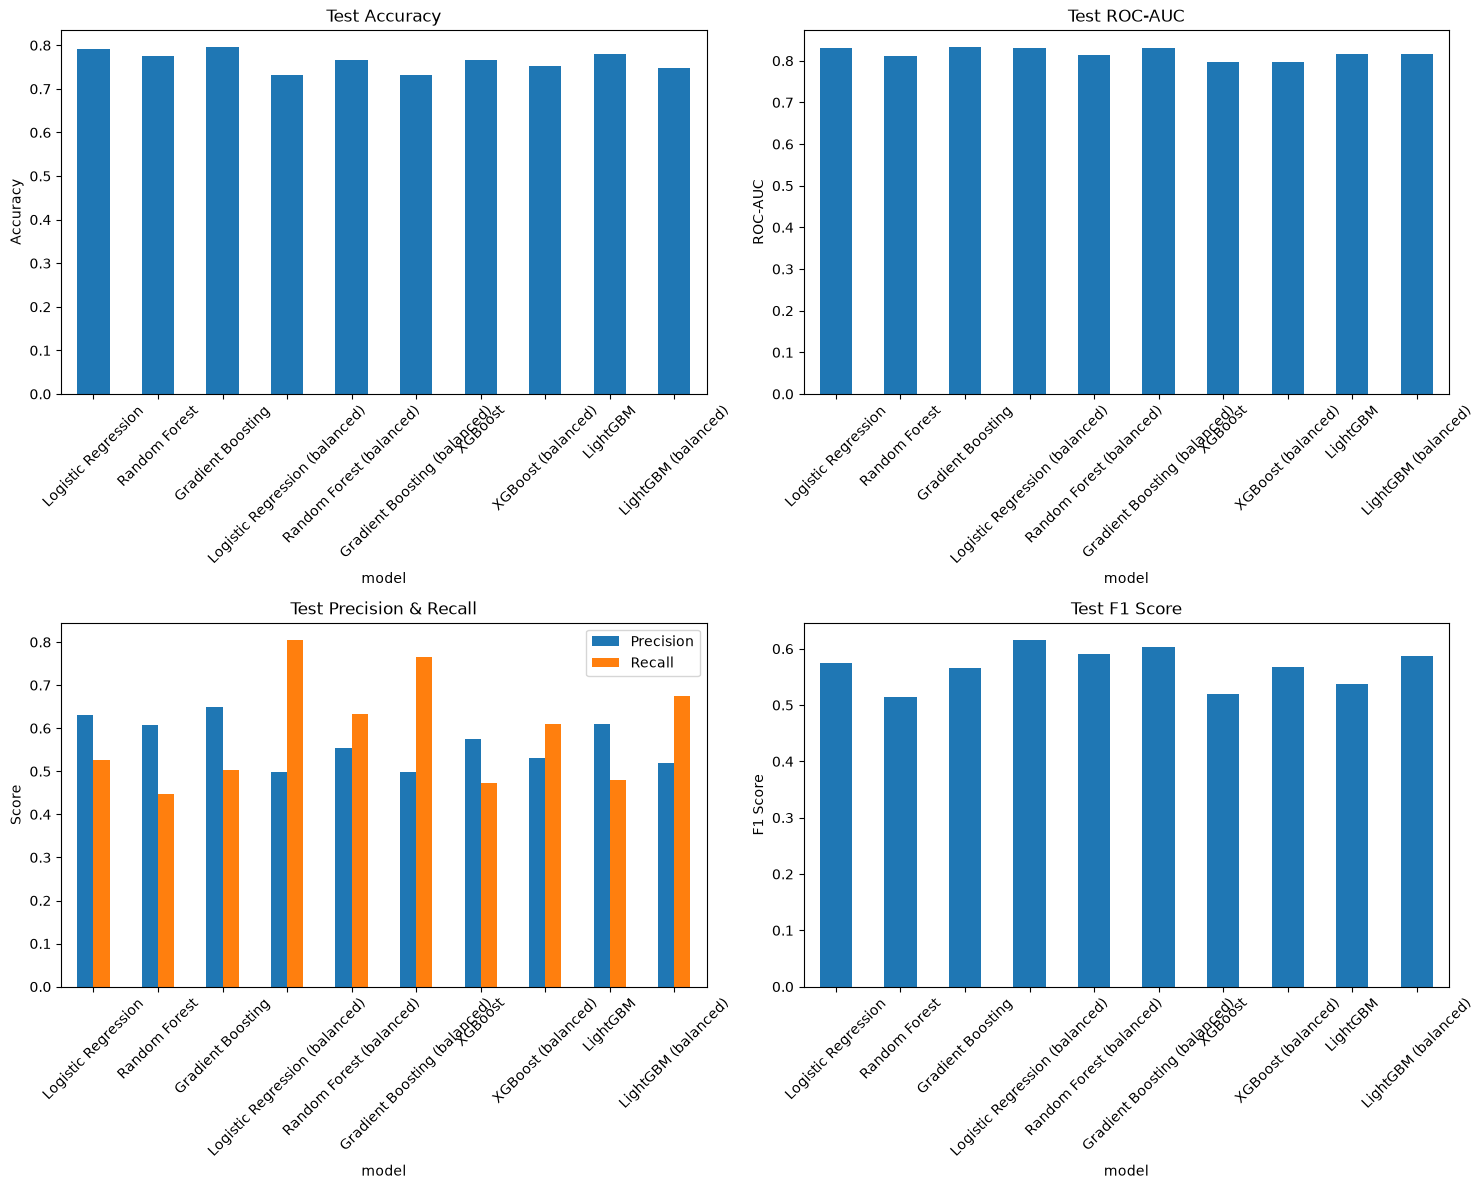

In [10]:
# Visualize model comparison
print("=== Visualizing Model Performance ===")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Test Accuracy
results_df['test_accuracy'].plot(kind='bar', ax=axes[0, 0])
axes[0, 0].set_title('Test Accuracy')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].tick_params(axis='x', rotation=45)

# Test ROC-AUC
results_df['test_roc_auc'].plot(kind='bar', ax=axes[0, 1])
axes[0, 1].set_title('Test ROC-AUC')
axes[0, 1].set_ylabel('ROC-AUC')
axes[0, 1].tick_params(axis='x', rotation=45)

# Test Precision and Recall
results_df[['test_precision', 'test_recall']].plot(kind='bar', ax=axes[1, 0])
axes[1, 0].set_title('Test Precision & Recall')
axes[1, 0].set_ylabel('Score')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend(['Precision', 'Recall'])

# Test F1
results_df['test_f1'].plot(kind='bar', ax=axes[1, 1])
axes[1, 1].set_title('Test F1 Score')
axes[1, 1].set_ylabel('F1 Score')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

=== ROC Curve for Gradient Boosting ===


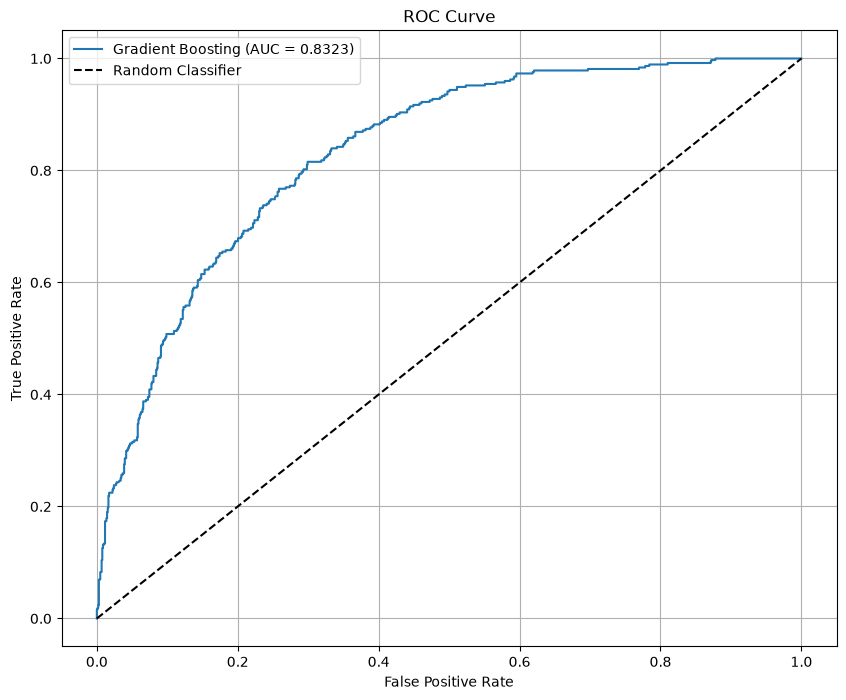

In [11]:
# ROC Curve for best model
print(f"=== ROC Curve for {best_model_name} ===")

best_model = trained_models[best_model_name]

if hasattr(best_model, 'predict_proba'):
    y_test_proba = best_model.predict_proba(X_test_features)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
    
    plt.figure(figsize=(10, 8))
    plt.plot(fpr, tpr, label=f'{best_model_name} (AUC = {best_score:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Model does not support probability predictions")

=== Confusion Matrix for Gradient Boosting ===


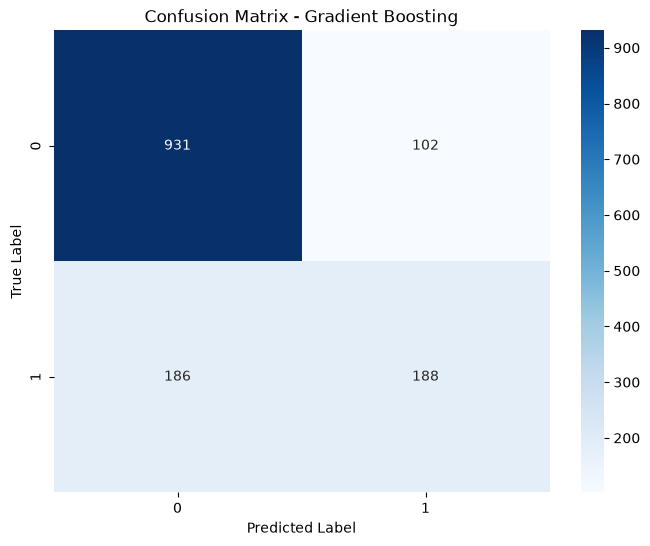

True Negatives: 931
False Positives: 102
False Negatives: 186
True Positives: 188


In [12]:
# Confusion Matrix for best model
print(f"=== Confusion Matrix for {best_model_name} ===")

y_test_pred = best_model.predict(X_test_features)
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print(f"True Negatives: {cm[0, 0]}")
print(f"False Positives: {cm[0, 1]}")
print(f"False Negatives: {cm[1, 0]}")
print(f"True Positives: {cm[1, 1]}")

=== Feature Importance for Gradient Boosting ===
                           feature  importance
36         Contract_Month-to-month    0.377478
1                           tenure    0.151492
16     InternetService_Fiber optic    0.083812
18               OnlineSecurity_No    0.067045
2                   MonthlyCharges    0.064594
27                  TechSupport_No    0.049566
3                     TotalCharges    0.046713
43  PaymentMethod_Electronic check    0.029720
45             avg_monthly_charges    0.015260
54              services_x_monthly    0.013481


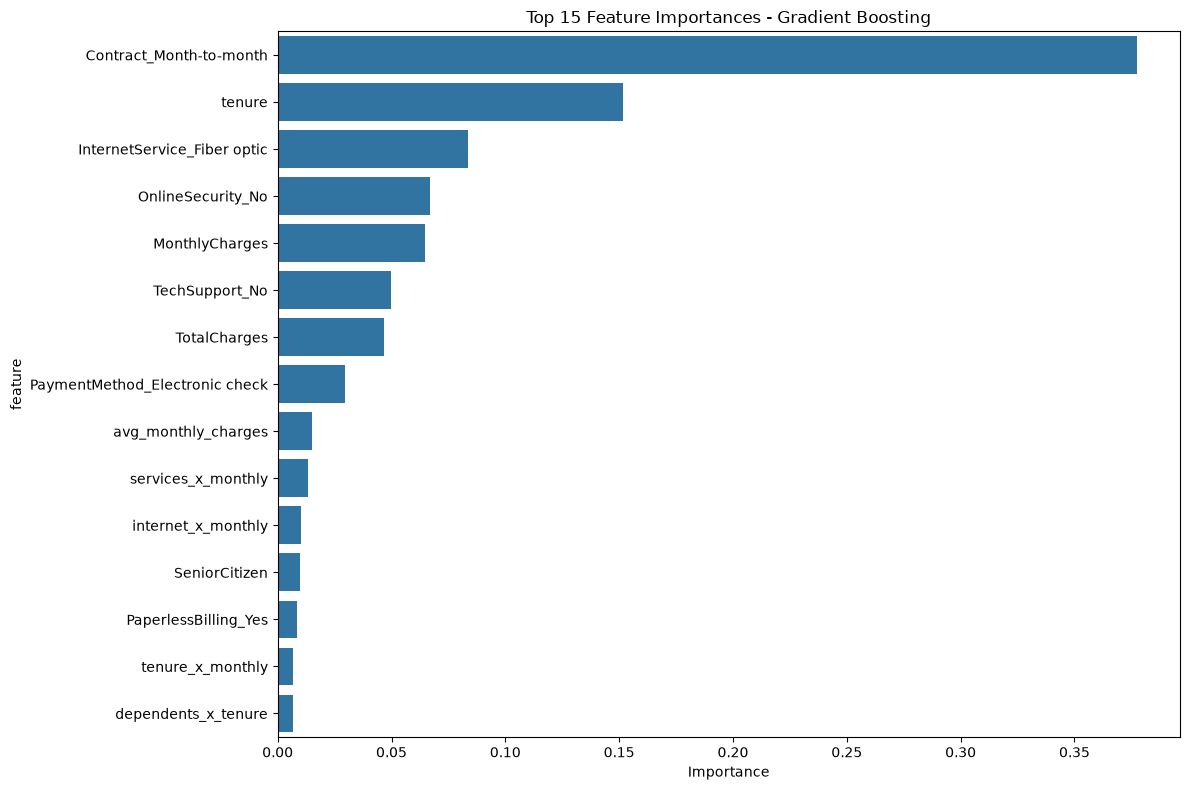

In [13]:
# Feature Importance (for tree-based models)
print(f"=== Feature Importance for {best_model_name} ===")

if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': X_train_features.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print(feature_importance.head(10))
    
    # Visualize
    plt.figure(figsize=(12, 8))
    sns.barplot(x='importance', y='feature', data=feature_importance.head(15))
    plt.title(f'Top 15 Feature Importances - {best_model_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
elif hasattr(best_model, 'coef_'):
    # For logistic regression
    feature_importance = pd.DataFrame({
        'feature': X_train_features.columns,
        'coefficient': best_model.coef_[0]
    }).sort_values('coefficient', key=abs, ascending=False)
    
    print(feature_importance.head(10))
    
    # Visualize
    plt.figure(figsize=(12, 8))
    feature_importance.head(15)['coefficient'].plot(kind='barh')
    plt.title(f'Top 15 Feature Coefficients - {best_model_name}')
    plt.xlabel('Coefficient')
    plt.tight_layout()
    plt.show()
else:
    print("Feature importance not available for this model")

In [14]:
# Save best model
print(f"=== Saving Best Model ===")

best_model_path = MODELS_DIR / f"{best_model_name.lower().replace(' ', '_')}.pkl"
with open(best_model_path, 'wb') as f:
    pickle.dump(best_model, f)

print(f"Saved best model: {best_model_path}")

# Save results
results_path = MODELS_DIR / "model_comparison_results.csv"
results_df.to_csv(results_path)
print(f"Saved results: {results_path}")

=== Saving Best Model ===
Saved best model: ../models/gradient_boosting.pkl
Saved results: ../models/model_comparison_results.csv


In [15]:
# Final Summary
print("=== Modeling Summary ===")
print(f"\nTotal models trained: {len(trained_models)} (baseline + class-balanced variants)")
print(f"Best performing model (ROC-AUC): {best_model_name}")
print(f"Best ROC-AUC: {best_score:.4f}")
print(f"\nModel performance ranking (by ROC-AUC):")
print(results_df['test_roc_auc'].sort_values(ascending=False).round(4))

print(f"\nKey insights:")
print(f"- Dataset is imbalanced (~{scale_pos_weight:.2f}:1 No:Yes); baselines under-detect churn (low recall).")
print(f"- class_weight='balanced' / scale_pos_weight raises churn recall, trading some precision.")
print(f"- ROC-AUC barely moves with balancing (it is threshold-independent) — judge by recall/F1.")
print(f"- Threshold tuning lets us pick an operating point for a target recall/precision trade-off.")
print(f"- SMOTE benchmark provides an alternative (resampling) comparison to class weighting.")

=== Modeling Summary ===

Total models trained: 10 (baseline + class-balanced variants)
Best performing model (ROC-AUC): Gradient Boosting
Best ROC-AUC: 0.8323

Model performance ranking (by ROC-AUC):
model
Gradient Boosting                 0.8323
Gradient Boosting (balanced)      0.8316
Logistic Regression               0.8300
Logistic Regression (balanced)    0.8299
LightGBM (balanced)               0.8157
LightGBM                          0.8153
Random Forest (balanced)          0.8150
Random Forest                     0.8125
XGBoost                           0.7981
XGBoost (balanced)                0.7961
Name: test_roc_auc, dtype: float64

Key insights:
- Dataset is imbalanced (~2.76:1 No:Yes); baselines under-detect churn (low recall).
- class_weight='balanced' / scale_pos_weight raises churn recall, trading some precision.
- ROC-AUC barely moves with balancing (it is threshold-independent) — judge by recall/F1.
- Threshold tuning lets us pick an operating point for a target reca

## Threshold Tuning (Option C)

Class weighting fixes *how the model learns*; threshold tuning fixes *how we act on its
outputs*. A trained classifier outputs a churn **probability**; the default 0.50 cutoff used
to turn that into a Yes/No decision is arbitrary and tends to under-predict the minority
class on imbalanced data.

Sweeping the threshold lets us pick an operating point on the precision/recall trade-off:

- **Lower threshold** -> more customers flagged as churners -> **higher recall, lower precision**.
- **Higher threshold** -> fewer flags -> higher precision, lower recall.

Below we sweep thresholds on the best model and report three operating points: the default
(0.50), the F1-maximizing threshold, and the highest-precision threshold that still achieves
recall >= 0.70 (a common business target for retention campaigns).

=== Threshold Tuning (Option C) ===


/Users/b/data/projects/telco-churn-analytics/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/b/data/projects/telco-churn-analytics/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/b/data/projects/telco-churn-analytics/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

Model: Gradient Boosting
Default (0.50):    precision=0.648  recall=0.503  f1=0.566
Best F1  (0.29):  precision=0.516  recall=0.767  f1=0.617
Recall>=0.70 (0.33):  precision=0.533  recall=0.706  f1=0.608


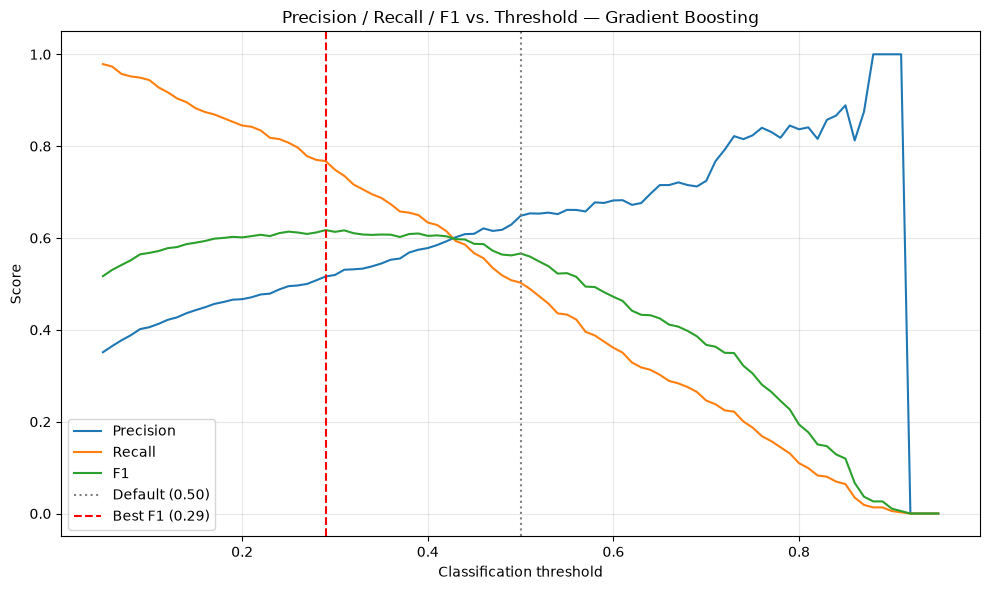


Why this matters: the default 0.50 cutoff is arbitrary for imbalanced data.
Choosing the threshold lets us deliberately favor recall (catch more churners)
when a missed churner costs more than a false alarm — the usual case for retention.


In [16]:
# Threshold tuning on the best model's predicted probabilities
print("=== Threshold Tuning (Option C) ===")

threshold_model = trained_models[best_model_name]
pos_idx = list(threshold_model.classes_).index(1)
proba = threshold_model.predict_proba(X_test_features)[:, pos_idx]

# Sweep candidate thresholds
thresholds = np.linspace(0.05, 0.95, 91)
rows = []
for t in thresholds:
    pred = (proba >= t).astype(int)
    rows.append({
        'threshold': t,
        'precision': precision_score(y_test, pred),
        'recall': recall_score(y_test, pred),
        'f1': f1_score(y_test, pred),
    })
sweep = pd.DataFrame(rows)

# Key operating points
default_row = sweep.iloc[(sweep['threshold'] - 0.5).abs().idxmin()]
best_f1_row = sweep.loc[sweep['f1'].idxmax()]
recall70 = sweep[sweep['recall'] >= 0.70]
recall70_row = recall70.sort_values('precision', ascending=False).iloc[0] if not recall70.empty else None

print(f"Model: {best_model_name}")
print(f"Default (0.50):    precision={default_row['precision']:.3f}  recall={default_row['recall']:.3f}  f1={default_row['f1']:.3f}")
print(f"Best F1  ({best_f1_row['threshold']:.2f}):  precision={best_f1_row['precision']:.3f}  recall={best_f1_row['recall']:.3f}  f1={best_f1_row['f1']:.3f}")
if recall70_row is not None:
    print(f"Recall>=0.70 ({recall70_row['threshold']:.2f}):  precision={recall70_row['precision']:.3f}  recall={recall70_row['recall']:.3f}  f1={recall70_row['f1']:.3f}")
else:
    print("No threshold reaches recall >= 0.70 on this model.")

# Visualize the trade-off
plt.figure(figsize=(10, 6))
plt.plot(sweep['threshold'], sweep['precision'], label='Precision')
plt.plot(sweep['threshold'], sweep['recall'], label='Recall')
plt.plot(sweep['threshold'], sweep['f1'], label='F1')
plt.axvline(0.5, color='gray', linestyle=':', label='Default (0.50)')
plt.axvline(best_f1_row['threshold'], color='red', linestyle='--',
            label=f"Best F1 ({best_f1_row['threshold']:.2f})")
plt.xlabel('Classification threshold')
plt.ylabel('Score')
plt.title(f'Precision / Recall / F1 vs. Threshold — {best_model_name}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nWhy this matters: the default 0.50 cutoff is arbitrary for imbalanced data.")
print("Choosing the threshold lets us deliberately favor recall (catch more churners)")
print("when a missed churner costs more than a false alarm — the usual case for retention.")

## SMOTE Benchmark (Option B)

SMOTE (*Synthetic Minority Over-sampling Technique*) is an **alternative** to class weighting:
instead of re-weighting the loss, it synthesizes new minority-class (churn) training examples
by interpolating between existing churners and their nearest neighbors, until the classes are
balanced.

Two important caveats are demonstrated below:

1. **Resample the training set only — never the test set.** Applying SMOTE before the
   train/test split (or to the test data) leaks information and inflates metrics.
2. SMOTE interpolates feature values, which is a weaker theoretical fit for the **one-hot
   encoded** categorical features that dominate this dataset. We therefore treat it as a
   *benchmark to compare against class weighting*, not as the default.

We do **not** stack SMOTE with `class_weight` — both attack the same training-stage problem and
combining them tends to over-predict churn. This run is kept separate from the saved comparison
so it does not alter the primary results.

In [18]:
# SMOTE benchmark — resampling alternative to class weighting
print("=== SMOTE Benchmark (Option B) ===")

try:
    from imblearn.over_sampling import SMOTE
    HAS_SMOTE = True
except ImportError:
    SMOTE = None
    HAS_SMOTE = False
    print("imbalanced-learn not installed. Install with: %pip install imbalanced-learn")

if HAS_SMOTE and SMOTE is not None:
    # Resample TRAINING data only (never the test set) to avoid leakage.
    smote = SMOTE(random_state=RANDOM_STATE)
    X_train_sm, y_train_sm = smote.fit_resample(X_train_features, y_train)
    print(f"Train class counts before SMOTE: {np.bincount(y_train).tolist()}")
    print(f"Train class counts after  SMOTE: {np.bincount(y_train_sm).tolist()}")

    # Same family as a strong model (Gradient Boosting) for a fair comparison.
    smote_model = GradientBoostingClassifier(random_state=RANDOM_STATE, n_estimators=100)
    _, smote_metrics = evaluate_model(
        smote_model, X_train_sm, X_test_features, y_train_sm, y_test,
        'Gradient Boosting (SMOTE)'
    )

    # Compare SMOTE vs. the class-weighted Gradient Boosting (test set)
    compare_rows = {
        'Gradient Boosting (baseline)': results_df.loc['Gradient Boosting', ['test_recall', 'test_precision', 'test_f1', 'test_roc_auc']]
            if 'Gradient Boosting' in results_df.index else None,
        'Gradient Boosting (balanced)': results_df.loc['Gradient Boosting (balanced)', ['test_recall', 'test_precision', 'test_f1', 'test_roc_auc']]
            if 'Gradient Boosting (balanced)' in results_df.index else None,
        'Gradient Boosting (SMOTE)': pd.Series({
            'test_recall': smote_metrics['test_recall'],
            'test_precision': smote_metrics['test_precision'],
            'test_f1': smote_metrics['test_f1'],
            'test_roc_auc': smote_metrics['test_roc_auc'],
        }),
    }
    compare_df = pd.DataFrame({k: v for k, v in compare_rows.items() if v is not None}).T
    print("\nClass weighting vs. SMOTE (Gradient Boosting):")
    print(compare_df.round(4))
    print("\nTakeaway: compare recall and F1. On this one-hot-heavy dataset, class weighting")
    print("is usually as good or better than SMOTE, with no extra dependency or leakage risk.")

=== SMOTE Benchmark (Option B) ===
Train class counts before SMOTE: [4130, 1495]
Train class counts after  SMOTE: [4130, 4130]

=== Gradient Boosting (SMOTE) ===
Train Accuracy: 0.8770
Test Accuracy: 0.7790
Train Precision: 0.8799
Test Precision: 0.5845
Train Recall: 0.8731
Test Recall: 0.5829
Train F1: 0.8765
Test F1: 0.5837
Train ROC-AUC: 0.9529
Test ROC-AUC: 0.8292

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1033
           1       0.58      0.58      0.58       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407


Class weighting vs. SMOTE (Gradient Boosting):
                              test_recall  test_precision  test_f1  \
Gradient Boosting (baseline)       0.5027          0.6483   0.5663   
Gradient Boosting (balanced)       0.7647          0.4983   0.6034   
Gradient Boos